## SAM

In [1]:
pip install opencv-python segment-anything

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/39.5 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/39.5 MB 9.5 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/39.5 MB 10.0 MB/s eta 0:00:04
   -------- ------------------------------- 8.1/39.5 MB 10.1 MB/s eta 0:00:04
   --------- ------------------------------ 8.9/39.5 MB 10.4 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/39.5 MB 10.4 MB/s eta 0:00:03
   ---------- ----------------------------- 10.2/39.5 MB 7.3 MB/s eta 0:00:04
   ------------ --------------------------- 12.3/39.5 MB 7.6 MB/s eta 0:00:04
   -------------- ------------------------- 14.7/39.5 MB 8.0 MB/s eta 0:00:04
   ---------------- ----------------------- 16.8/39.5 MB 8.1 MB/s eta 0:00:03
   ------------------- -------------------- 18.9/39.5 MB 8.3 MB/s eta 0:00:03
   -------------------- ------------------- 20.4/39.5 MB 8.3 MB/s eta 0:00

In [3]:
import requests

url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
checkpoint_path = "sam_vit_b.pth"

print("Downloading SAM checkpoint (may take a few minutes)...")
with open(checkpoint_path, "wb") as f:
    f.write(requests.get(url).content)

print("Download complete.")


Download complete.


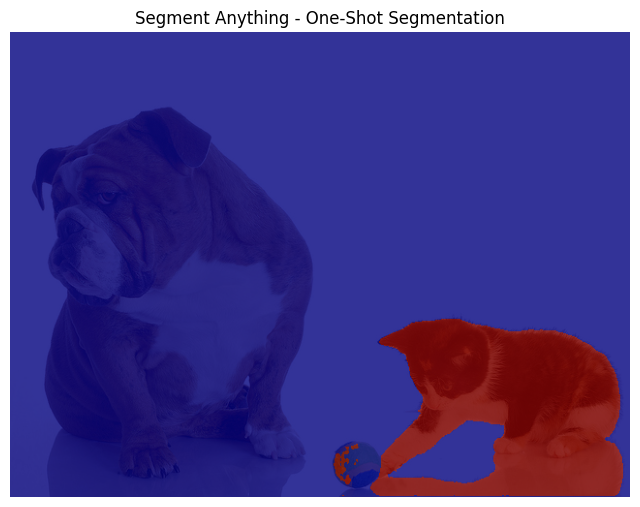

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor

# --- Load image ---
#image_path = "example_image.jpg"
image_path = "COCO2.jpg"
#image_path = "COCO1.jpg"# Replace with your own image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- Load SAM Model (ViT-H, ViT-B or ViT-L) ---
sam_checkpoint = "sam_vit_b.pth"  # Download from: https://github.com/facebookresearch/segment-anything#model-checkpoints
model_type = "vit_b"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
predictor = SamPredictor(sam)
predictor.set_image(image_rgb)

# --- Define one-shot bounding box manually or from detection ---
# Format: [x_min, y_min, x_max, y_max]
input_box = np.array([[320, 240, 640, 480]])  # Example box (edit as needed)

# --- Run SAM Prediction ---
masks, scores, logits = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box,
    multimask_output=True,
)

# --- Visualize the best mask ---
best_mask = masks[np.argmax(scores)]

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.8, cmap="jet")
plt.title("Segment Anything - One-Shot Segmentation")
plt.axis("off")
plt.show()


## Owl-ViT + SAM

OWL-ViT detected 2 objects for prompt: a dog


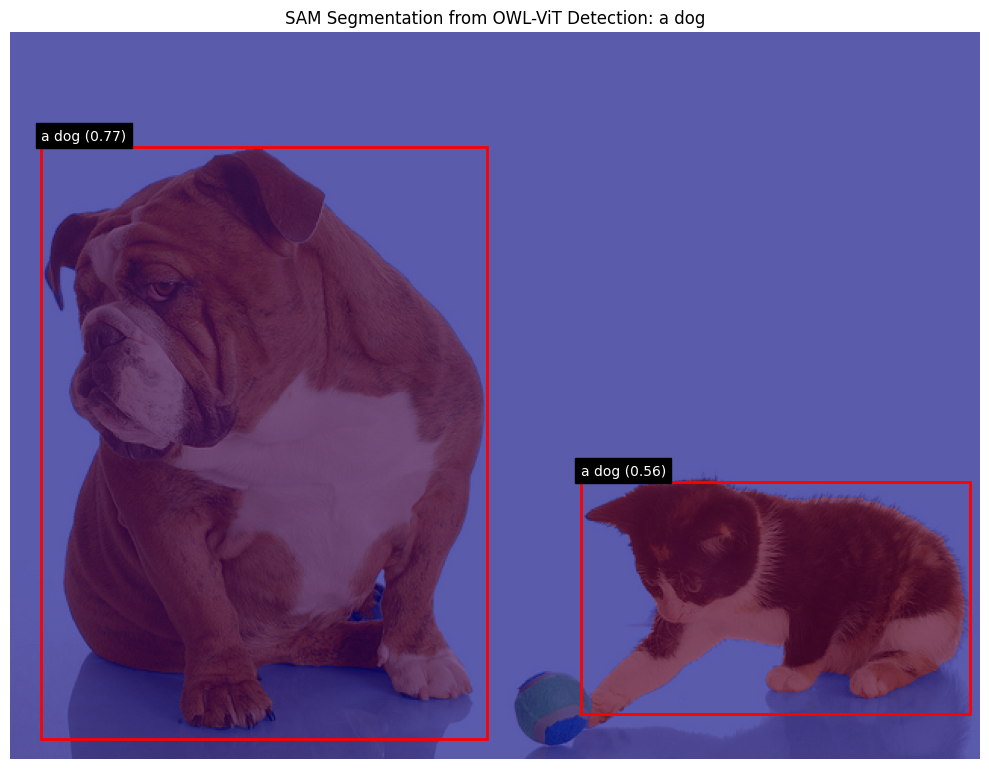

In [6]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from segment_anything import sam_model_registry, SamPredictor

# --- Load image ---
image_path = "COCO2.jpg"  # Replace with your image path
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(image_rgb)

# --- TEXT PROMPT ---
prompt = [["a ball"]]  # Change as needed
prompt = [["a dog"]]  # Change as needed

# --- OWL-ViT: detect bounding boxes from text prompt ---
processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
owlvit = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

inputs = processor(text=prompt, images=image_pil, return_tensors="pt")
with torch.no_grad():
    outputs = owlvit(**inputs)

target_size = torch.tensor([image_pil.size[::-1]])  # (height, width)
results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_size, threshold=0.3)[0]

boxes = results["boxes"]
scores = results["scores"]
labels = results["labels"]

print(f"OWL-ViT detected {len(boxes)} objects for prompt: {prompt[0][0]}")

# --- Load SAM model ---
sam_checkpoint = "sam_vit_b.pth"  # Downloaded checkpoint
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)
predictor = SamPredictor(sam)
predictor.set_image(image_rgb)

# --- Run SAM on each bounding box ---
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
ax = plt.gca()

for i, box in enumerate(boxes):
    box_np = box.numpy().astype(np.int32)
    x0, y0, x1, y1 = box_np
    input_box = np.array([box_np])  # shape: (1, 4)
    
    masks, scores_sam, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box,
        multimask_output=True
    )
    
    best_mask = masks[np.argmax(scores_sam)]
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='red', facecolor='none', linewidth=2))
    ax.imshow(best_mask, alpha=0.4, cmap='jet')

    ax.text(x0, y0 - 5, f"{prompt[0][labels[i]]} ({scores[i]:.2f})", color="white", backgroundcolor="black")

plt.axis("off")
plt.title(f"SAM Segmentation from OWL-ViT Detection: {prompt[0][0]}")
plt.tight_layout()
plt.show()


Exercises

- Implement the code to save the resultant segmentation image.
- Change the image, the object prompt and the threshold and see the results.
- Do the segmentation with a COCO image from the Internet, comment the results.
- Do the segmentation but this time with a more scarce image type, comment the results.
- Do the segmentation with a longer prompt, comment the result.
- Do the segmentation with a prompt in spanish, comment the result.
- Implementa los siguientes scripts y describe que hace cada uno.
  

In [ ]:
pythonplt.figure()
plt.imshow(image_rgb)
plt.title("Mueve el mouse para ver coordenadas")
plt.show()
# Las coordenadas aparecen en la barra inferior de la ventana

In [ ]:
coords = []

def onclick(event):
    if event.xdata and event.ydata:
        coords.append((int(event.xdata), int(event.ydata)))
        print(f"Click {len(coords)}: x={int(event.xdata)}, y={int(event.ydata)}")
        if len(coords) == 2:
            print(f"\ninput_box = np.array([[{coords[0][0]}, {coords[0][1]}, {coords[1][0]}, {coords[1][1]}]])")

fig, ax = plt.subplots()
ax.imshow(image_rgb)
ax.set_title("Click esquina SUPERIOR-IZQUIERDA, luego INFERIOR-DERECHA")
fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()